# Pathological Gait & Activity Recognition
**Goal:** Detect pathological walking patterns (Parkinson's, Huntington's) vs healthy controls using wearable-style force sensor signals — outside a clinical setting.

**Pipeline:** PhysioNet GaitNDD → Sliding Window → CNN + BiLSTM → Classification + Grad-CAM Explainability

## Phase 1: Environment & Data Acquisition

In [1]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 801.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 32.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


In [2]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print(f"TensorFlow version: {tf.__version__}")

# Download dataset
if not os.path.exists('gait_data'):
    print("Downloading PhysioNet GaitNDD Database...")
    wfdb.dl_database('gaitndd', dl_dir='gait_data')
else:
    print("Dataset already downloaded.")

TensorFlow version: 2.19.0
Generating record list for: als1
Generating record list for: als10
Generating record list for: als11
Generating record list for: als12
Generating record list for: als13
Generating record list for: als2
Generating record list for: als3
Generating record list for: als4
Generating record list for: als5
Generating record list for: als6
Generating record list for: als7
Generating record list for: als8
Generating record list for: als9
Generating record list for: control1
Generating record list for: control10
Generating record list for: control11
Generating record list for: control12
Generating record list for: control13
Generating record list for: control14
Generating record list for: control15
Generating record list for: control16
Generating record list for: control2
Generating record list for: control3
Generating record list for: control4
Generating record list for: control5
Generating record list for: control6
Generating record list for: control7
Generating reco

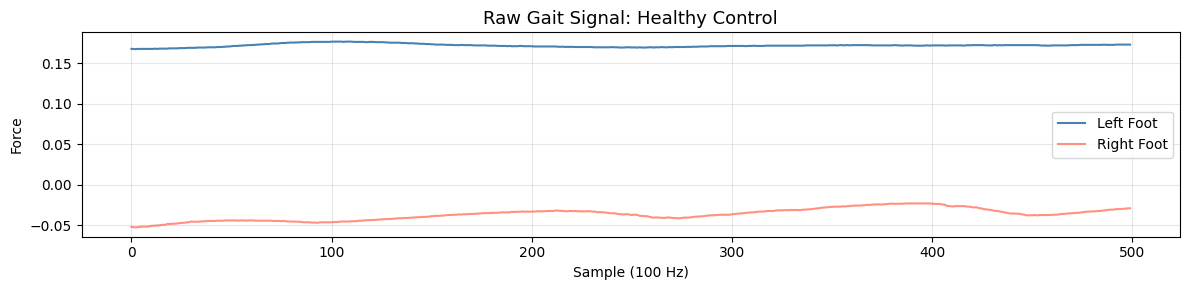

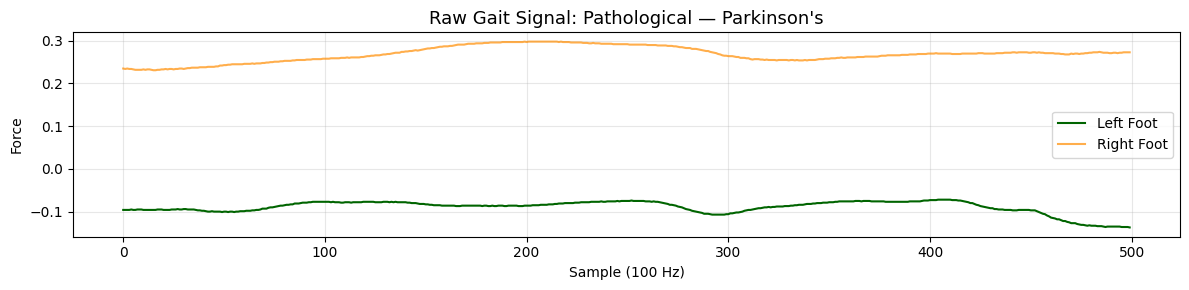

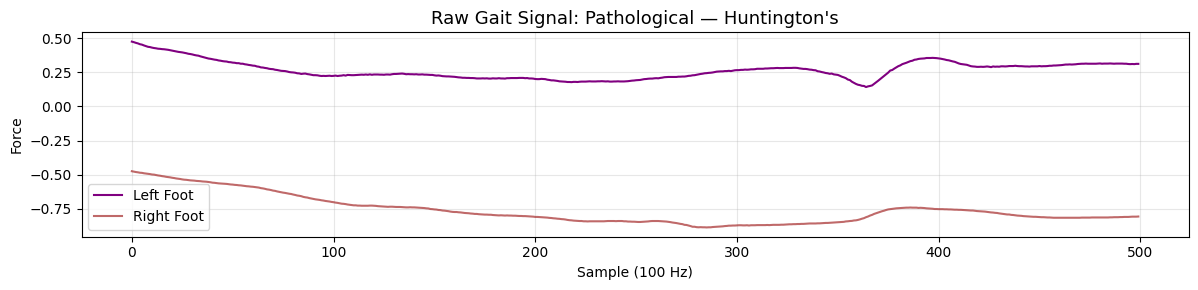

In [3]:
# --- Exploratory Data Analysis ---
# GaitNDD has 3 groups: control (healthy), park (Parkinson's), hunt (Huntington's)

def plot_clinical_signals(record_name, title, color_l='blue', color_r='red'):
    record = wfdb.rdrecord(f'gait_data/{record_name}')
    plt.figure(figsize=(12, 3))
    plt.plot(record.p_signal[:500, 0], label='Left Foot', color=color_l)
    plt.plot(record.p_signal[:500, 1], label='Right Foot', color=color_r, alpha=0.7)
    plt.title(f"Raw Gait Signal: {title}", fontsize=13)
    plt.xlabel("Sample (100 Hz)")
    plt.ylabel("Force")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_clinical_signals('control1', 'Healthy Control', 'steelblue', 'tomato')
plot_clinical_signals('park1',    "Pathological — Parkinson's", 'darkgreen', 'darkorange')
plot_clinical_signals('hunt1',    "Pathological — Huntington's", 'purple', 'brown')

## Phase 2: Preprocessing & Dataset Preparation

In [4]:
WINDOW_SIZE = 900   # 9 seconds at 100 Hz — captures multiple full gait cycles
STEP_SIZE   = 450   # 50% overlap for data augmentation

# Label map — we keep 3 classes for clinical relevance
# 0 = Healthy, 1 = Parkinson's, 2 = Huntington's
def get_label(rec_name):
    if 'control' in rec_name: return 0
    if 'park'    in rec_name: return 1
    if 'hunt'    in rec_name: return 2
    return None   # unknown — will be skipped

CLASS_NAMES = ['Healthy', "Parkinson's", "Huntington's"]

def prepare_clean_dataset():
    all_files = [f.replace('.hea', '') for f in os.listdir('gait_data') if f.endswith('.hea')]
    X_list, y_list = [], []
    skipped = 0

    for rec in all_files:
        label = get_label(rec)
        if label is None:
            skipped += 1
            continue

        try:
            record = wfdb.rdrecord(f'gait_data/{rec}')
            sig = record.p_signal[:, :2]  # Left and right foot pressure sensors

            # Z-score normalization: makes all signals comparable regardless of sensor scale
            std = np.std(sig)
            if std < 1e-7:
                print(f"  [WARN] {rec} has near-zero variance — skipping.")
                skipped += 1
                continue
            sig = (sig - np.mean(sig)) / (std + 1e-7)

            # Sliding window segmentation
            for i in range(0, len(sig) - WINDOW_SIZE, STEP_SIZE):
                chunk = sig[i : i + WINDOW_SIZE]
                if not np.isnan(chunk).any():
                    X_list.append(chunk)
                    y_list.append(label)

        except Exception as e:
            print(f"  [ERROR] Skipping {rec}: {e}")
            skipped += 1
            continue

    print(f"\nLoaded {len(X_list)} windows from {len(all_files) - skipped} records. Skipped: {skipped}")
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)

X, y = prepare_clean_dataset()

# Show class distribution
for i, name in enumerate(CLASS_NAMES):
    print(f"  Class {i} ({name}): {np.sum(y == i)} windows")


Loaded 8712 windows from 51 records. Skipped: 13
  Class 0 (Healthy): 2574 windows
  Class 1 (Parkinson's): 2772 windows
  Class 2 (Huntington's): 3366 windows


In [5]:
# --- Proper 3-way split: Train / Validation / Test ---
# Validation is used during training (early stopping).
# Test set is held out and NEVER seen during training.

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print(f"Train:      {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples  ← never seen during training")

Train:      6294 samples
Validation: 1111 samples
Test:       1307 samples  ← never seen during training


## Phase 3: Model Architecture — CNN + Bidirectional LSTM

**Why this design?**
- **Conv1D layers** act like a local pattern detector — they find features like heel-strike sharpness or toe-off asymmetry within a short time window.
- **BatchNormalization** keeps activations stable and speeds up training.
- **Bidirectional LSTM** reads the gait sequence both forward and backward, capturing the rhythm of a complete stride cycle.
- **Dropout** randomly turns off neurons during training to prevent memorization.
- **Softmax output** gives a probability for each of the 3 classes.

In [6]:
NUM_CLASSES = 3

model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 2)),

    # --- Block 1: Local Feature Extraction ---
    # kernel_size=5 scans 5 consecutive samples (~50 ms) at a time
    layers.Conv1D(128, kernel_size=5, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),   # Halve the time resolution → 450 steps

    # --- Block 2: Finer Pattern Detection ---
    layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),   # → 225 steps

    # --- Block 3: Temporal Rhythm Analysis ---
    # Bidirectional = reads gait sequence forward AND backward
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.4),

    # --- Classifier Head ---
    layers.Dense(32, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')   # 3-class output
], name="GaitNet_CNN_BiLSTM")

# clipnorm=1.0 prevents gradient explosion (NaN loss fix)
opt = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(
    optimizer=opt,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "GaitNet_CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 900, 128)       │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 900, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 450, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 450, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 450, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 225, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,091 (379.26 KB)

 Trainable params: 96,707 (377.76 KB)

 Non-trainable params: 384 (1.50 KB)

## Phase 4: Balanced Training

In [ ]:
# Handle class imbalance: rarer classes get higher weight during loss computation
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: cw[i] for i in range(len(cw))}
print("Class weights:", {CLASS_NAMES[k]: round(v, 3) for k, v in cw_dict.items()})

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
)

print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),   # ← clean validation set, NOT test
    class_weight=cw_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights: {'Healthy': np.float64(1.128), "Parkinson's": np.float64(1.048), "Huntington's": np.float64(0.863)}

Starting training...
Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 77s 700ms/step - accuracy: 0.4131 - loss: 1.0760 - val_accuracy: 0.3879 - val_loss: 1.0892 - learning_rate: 1.0000e-04
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 67s 682ms/step - accuracy: 0.4655 - loss: 1.0275 - val_accuracy: 0.3888 - val_loss: 1.0925 - learning_rate: 1.0000e-04
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 67s 681ms/step - accuracy: 0.5033 - loss: 0.9953 - val_accuracy: 0.3960 - val_loss: 1.0814 - learning_rate: 1.0000e-04
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 69s 693ms/step - accuracy: 0.5383 - loss: 0.9637 - val_accuracy: 0.4032 - val_loss: 1.0615 - learning_rate: 1.0000e-04
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 84s 712ms/step - accuracy: 0.5675 - loss: 0.9219 - val_accuracy: 0.4617 - val_loss: 1.0188 - learning_rate: 1.0000e-04
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 80s 698ms/step - accuracy: 0.5958 - loss

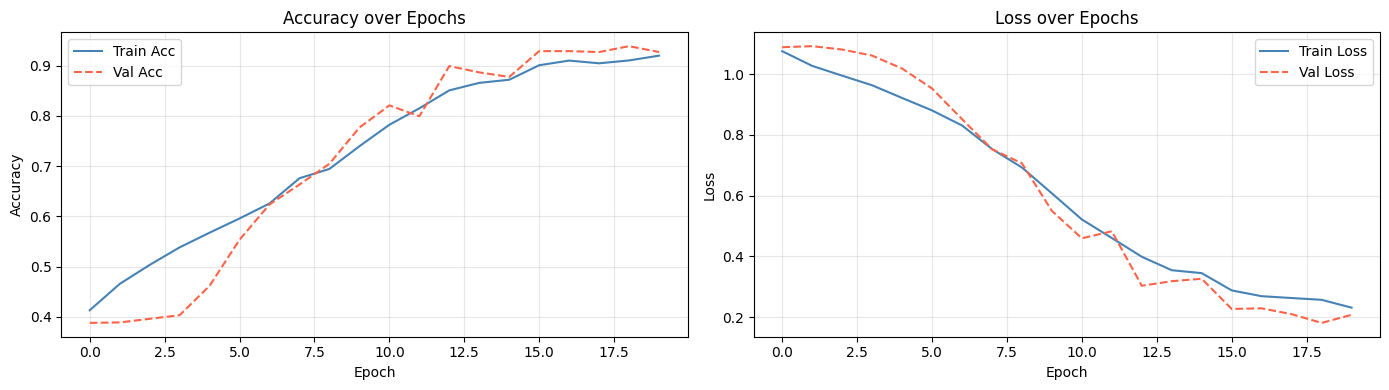

In [8]:
# --- Training History Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'],     label='Train Acc', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 5: Evaluation on Held-Out Test Set

      GAIT DIAGNOSIS — EVALUATION REPORT
              precision    recall  f1-score   support

     Healthy       0.94      0.96      0.95       386
 Parkinson's       0.90      0.92      0.91       416
Huntington's       0.93      0.91      0.92       505

    accuracy                           0.92      1307
   macro avg       0.92      0.93      0.93      1307
weighted avg       0.92      0.92      0.92      1307



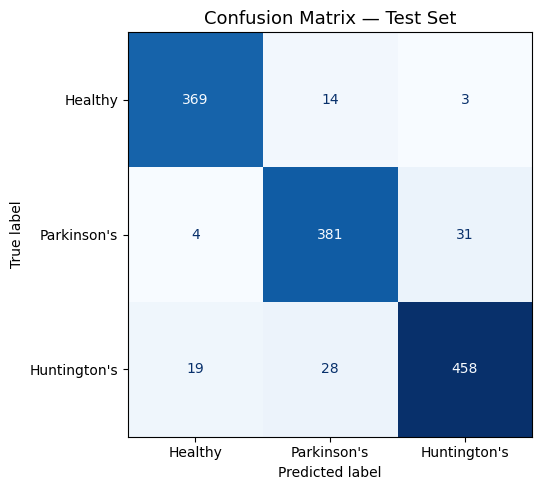

In [9]:
# Predict on the truly unseen test set
y_probs = model.predict(X_test, verbose=0)   # shape: (N, 3)
y_pred  = np.argmax(y_probs, axis=1)

print("=" * 50)
print("      GAIT DIAGNOSIS — EVALUATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm_matrix = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# --- Per-Sample Diagnosis with Consistent Confidence Display ---
def diagnose_sample(idx):
    probs      = y_probs[idx]              # probability for each class
    pred_class = np.argmax(probs)          # predicted class index
    confidence = probs[pred_class] * 100   # confidence = probability of predicted class
    true_class = y_test[idx]

    print(f"Sample #{idx}")
    print(f"  True label:      {CLASS_NAMES[true_class]}")
    print(f"  Predicted:       {CLASS_NAMES[pred_class]}")
    print(f"  Confidence:      {confidence:.1f}%")
    print(f"  All probs:       ", {CLASS_NAMES[i]: f"{probs[i]*100:.1f}%" for i in range(3)})
    return pred_class

# Try a few samples
for i in [0, 1, 2]:
    diagnose_sample(i)
    print()

Sample #0
  True label:      Huntington's
  Predicted:       Huntington's
  Confidence:      99.1%
  All probs:        {'Healthy': '0.4%', "Parkinson's": '0.5%', "Huntington's": '99.1%'}

Sample #1
  True label:      Healthy
  Predicted:       Healthy
  Confidence:      97.1%
  All probs:        {'Healthy': '97.1%', "Parkinson's": '0.6%', "Huntington's": '2.3%'}

Sample #2
  True label:      Healthy
  Predicted:       Healthy
  Confidence:      99.1%
  All probs:        {'Healthy': '99.1%', "Parkinson's": '0.1%', "Huntington's": '0.8%'}



## Phase 6: Grad-CAM Explainability — Which Gait Phase Triggered the Alert?

**Grad-CAM (Gradient-weighted Class Activation Mapping)** answers the question:
*"Which part of the gait signal caused the model to predict this class?"*

**How it works (step by step):**
1. Pick the last Conv1D layer — it holds the richest feature maps.
2. For a given input, compute the gradient of the predicted class score with respect to that layer's output.
3. Average the gradients across the feature dimension → importance weights.
4. Multiply weights by the feature maps and sum → a 1D heatmap over time.
5. Overlay on the original signal — hot regions = important gait phases.

Grad-CAM function ready.
Conv layers in model:
  'conv1d'
  'conv1d_1'
Generating Grad-CAM explanation for one sample per class...

── Healthy ──


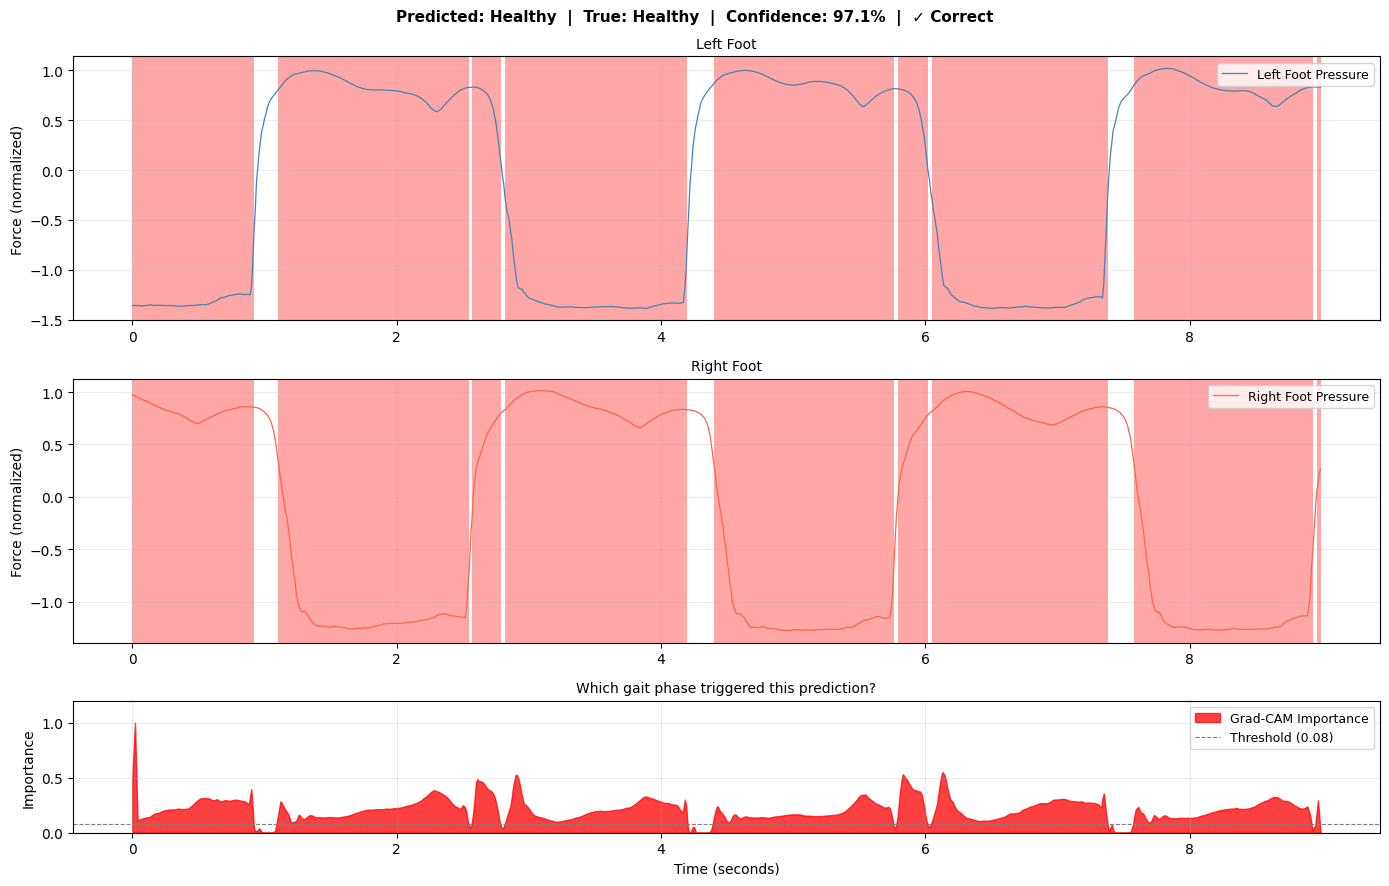


── Parkinson's ──


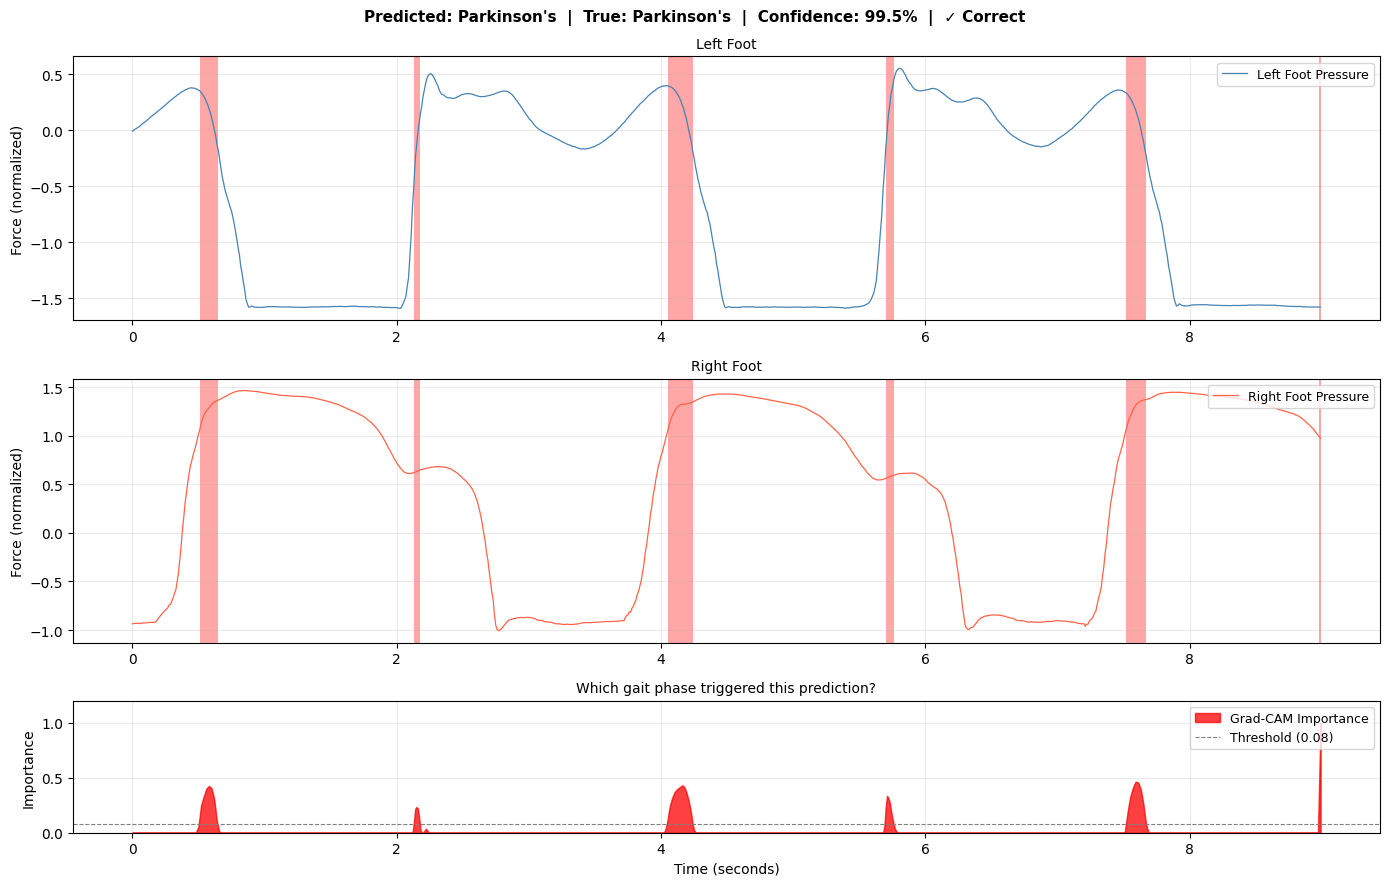


── Huntington's ──


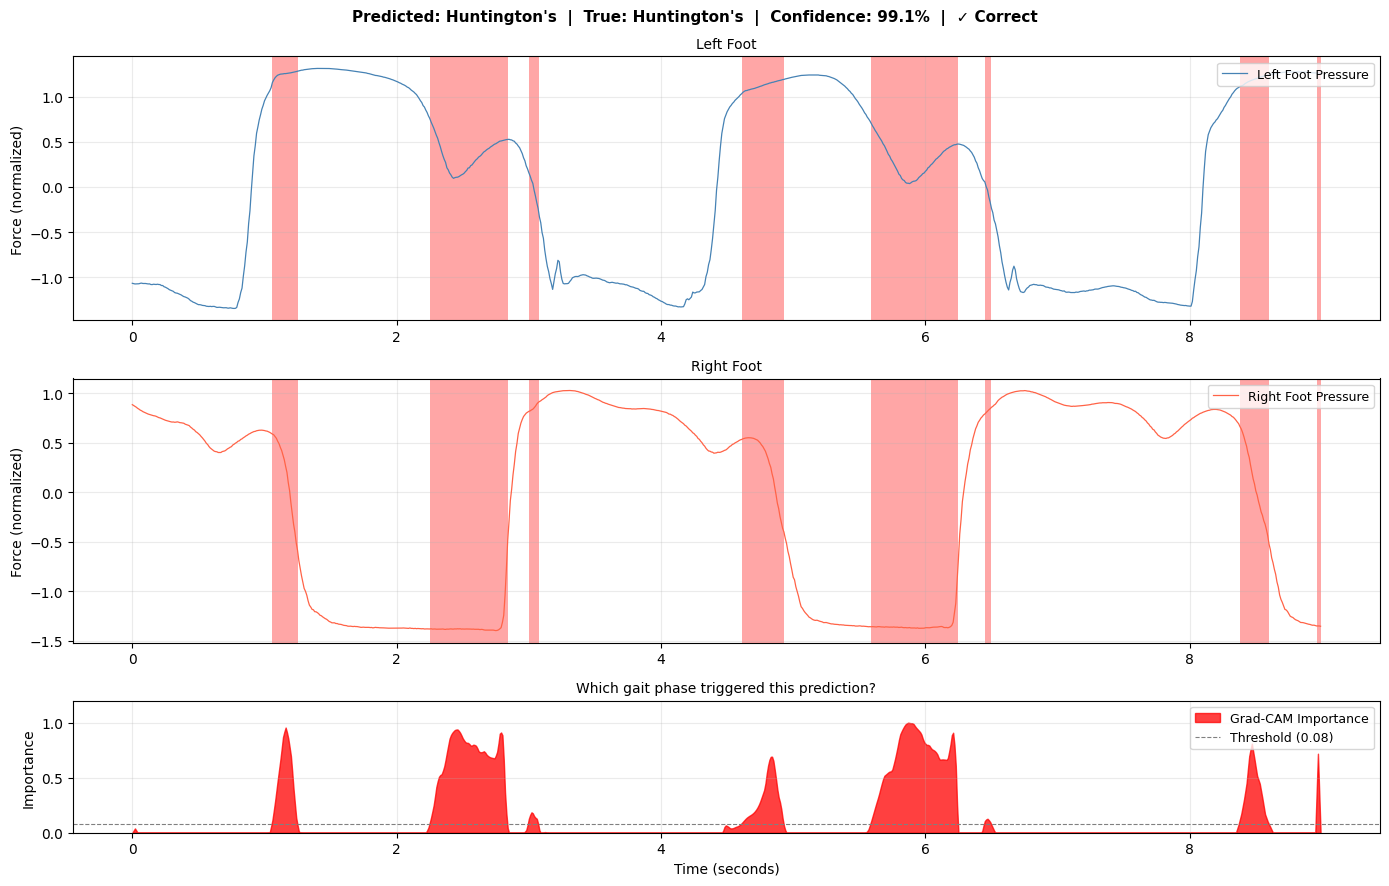

In [17]:
def compute_gradcam_1d(model, input_signal, class_idx, last_conv_layer_name='conv1d_1'):

    input_batch = tf.cast(input_signal[np.newaxis, ...], tf.float32)

    # ── Step 1: Rebuild graph tapping into conv layer output ──
    # We cannot use model.input directly in Keras 3 Sequential models,
    # so we replay each layer manually through a fresh Input node.
    inp = tf.keras.Input(shape=(WINDOW_SIZE, 2))
    x = inp
    conv_out_tensor = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_out_tensor = x    # capture output right after this layer

    if conv_out_tensor is None:
        print(f"Layer '{last_conv_layer_name}' not found in model.")
        return np.zeros(WINDOW_SIZE)

    # Sub-model: input → [conv layer output, final prediction]
    grad_model = tf.keras.Model(inputs=inp, outputs=[conv_out_tensor, x])

    # ── Step 2: Forward pass, watching the conv output ──
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(input_batch, training=False)
        tape.watch(conv_outputs)
        class_score = predictions[:, class_idx]

    # ── Step 3: Gradient of class score w.r.t. conv output ──
    # Shape: (1, 450, 64) — gradient for every time step and filter
    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        print("Gradients are None — try: tf.config.run_functions_eagerly(True)")
        return np.zeros(WINDOW_SIZE)

    # ── Step 4: Pool gradients across filters → (64,) weights ──
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1)).numpy()

    # Dot product with conv activations: (450, 64) · (64,) → (450,)
    conv_outputs_np = conv_outputs[0].numpy()
    heatmap = np.dot(conv_outputs_np, pooled_grads)

    # ── Step 5: ReLU + upsample to original signal length ──
    heatmap = np.maximum(heatmap, 0)

    heatmap_resized = np.interp(
        np.linspace(0, len(heatmap) - 1, WINDOW_SIZE),
        np.arange(len(heatmap)),
        heatmap
    )

    # Normalize to [0, 1]
    if heatmap_resized.max() > 0:
        heatmap_resized /= heatmap_resized.max()

    return heatmap_resized


print("Grad-CAM function ready.")
print("Conv layers in model:")
for layer in model.layers:
    if 'conv' in layer.name:
        print(f"  '{layer.name}'")







def plot_gradcam_explanation(sample_idx, last_conv_name='conv1d_1'):
    """
    Plots the gait signal for one test sample with a red
    heatmap overlay showing where the model focused.
    Three subplots:
      1. Left foot pressure + red overlay
      2. Right foot pressure + red overlay
      3. Clean importance bar (easier to read)
    """
    signal     = X_test[sample_idx]
    true_label = y_test[sample_idx]
    pred_label = y_pred[sample_idx]
    confidence = y_probs[sample_idx][pred_label] * 100

    heatmap   = compute_gradcam_1d(model, signal, pred_label, last_conv_name)
    time_axis = np.arange(WINDOW_SIZE) / 100.0    # samples → seconds

    correct_str = "✓ Correct" if true_label == pred_label else "✗ Wrong"
    fig_title   = (f"Predicted: {CLASS_NAMES[pred_label]}  |  "
                   f"True: {CLASS_NAMES[true_label]}  |  "
                   f"Confidence: {confidence:.1f}%  |  {correct_str}")

    fig, axes = plt.subplots(3, 1, figsize=(14, 9),
                             gridspec_kw={'height_ratios': [2, 2, 1]})
    fig.suptitle(fig_title, fontsize=11, fontweight='bold')

    # ── Subplot 1: Left foot ──
    ax1 = axes[0]
    ax1.plot(time_axis, signal[:, 0], color='steelblue',
             linewidth=0.9, label='Left Foot Pressure')
    ax1.set_ylabel('Force (normalized)')
    ax1.set_title('Left Foot', fontsize=10)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(alpha=0.25)

    # ── Subplot 2: Right foot ──
    ax2 = axes[1]
    ax2.plot(time_axis, signal[:, 1], color='tomato',
             linewidth=0.9, label='Right Foot Pressure')
    ax2.set_ylabel('Force (normalized)')
    ax2.set_title('Right Foot', fontsize=10)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(alpha=0.25)

    # Red overlay on both signal plots
    # Build contiguous spans for speed instead of per-sample axvspan
    in_span   = False
    span_start = 0.0
    THRESHOLD  = 0.08

    for i in range(WINDOW_SIZE):
        val = heatmap[i]
        t   = time_axis[i]
        if val > THRESHOLD and not in_span:
            span_start = t
            in_span    = True
        elif val <= THRESHOLD and in_span:
            for ax in [ax1, ax2]:
                ax.axvspan(span_start, t, alpha=0.35, color='red', linewidth=0)
            in_span = False
    if in_span:   # close any open span at the end
        for ax in [ax1, ax2]:
            ax.axvspan(span_start, time_axis[-1], alpha=0.35, color='red', linewidth=0)

    # ── Subplot 3: Importance bar ──
    ax3 = axes[2]
    ax3.fill_between(time_axis, heatmap, color='red', alpha=0.75,
                     label='Grad-CAM Importance')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_ylabel('Importance')
    ax3.set_title('Which gait phase triggered this prediction?', fontsize=10)
    ax3.set_ylim(0, 1.2)
    ax3.axhline(y=THRESHOLD, color='gray', linestyle='--',
                linewidth=0.8, label=f'Threshold ({THRESHOLD})')
    ax3.legend(loc='upper right', fontsize=9)
    ax3.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ── Run for one sample of each class ──
print("Generating Grad-CAM explanation for one sample per class...\n")

for target_class in range(3):
    idxs = np.where(y_test == target_class)[0]
    if len(idxs) == 0:
        print(f"No test samples found for class: {CLASS_NAMES[target_class]}")
        continue
    print(f"── {CLASS_NAMES[target_class]} ──")
    plot_gradcam_explanation(idxs[0], last_conv_name='conv1d_1')
    print()

